In [187]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

In [188]:
# Read the dataset
Weather = pd.read_csv('../Datasets/Forecasting_Data.csv')
Weather.head()

,UpdatedAt,Country,CountryCode,State,StateCode,City,CityID,Latitude,Longitude,WeatherCondition,...,NO,NO2,O3,SO2,PM25,PM10,NH3,CreatedAt,Date,AQI_Category
0,2025-06-01 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Rain,...,4.43,38.19,70.04,10.91,36.54,53.71,3.60,2025-06-01 12:00:00,2025-06-01,Satisfactory
1,2025-06-02 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Rain,...,8.74,20.16,42.95,7.57,48.00,68.64,14.81,2025-06-02 12:00:00,2025-06-02,Satisfactory
2,2025-06-03 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Thunderstorm,...,14.69,20.85,31.69,9.73,37.52,53.28,13.21,2025-06-03 12:00:00,2025-06-03,Satisfactory
3,2025-06-04 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clear,...,16.81,54.36,56.80,4.64,63.84,91.93,14.59,2025-06-04 12:00:00,2025-06-04,Moderate
4,2025-06-05 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clouds,...,15.13,9.56,16.31,20.10,57.96,89.84,10.07,2025-06-05 12:00:00,2025-06-05,Moderate


In [189]:
Weather_Forecast = Weather.copy()
Weather_Forecast

,UpdatedAt,Country,CountryCode,State,StateCode,City,CityID,Latitude,Longitude,WeatherCondition,...,NO,NO2,O3,SO2,PM25,PM10,NH3,CreatedAt,Date,AQI_Category
0,2025-06-01 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Rain,...,4.43,38.19,70.04,10.91,36.54,53.71,3.60,2025-06-01 12:00:00,2025-06-01,Satisfactory
1,2025-06-02 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Rain,...,8.74,20.16,42.95,7.57,48.00,68.64,14.81,2025-06-02 12:00:00,2025-06-02,Satisfactory
2,2025-06-03 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Thunderstorm,...,14.69,20.85,31.69,9.73,37.52,53.28,13.21,2025-06-03 12:00:00,2025-06-03,Satisfactory
3,2025-06-04 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clear,...,16.81,54.36,56.80,4.64,63.84,91.93,14.59,2025-06-04 12:00:00,2025-06-04,Moderate
4,2025-06-05 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clouds,...,15.13,9.56,16.31,20.10,57.96,89.84,10.07,2025-06-05 12:00:00,2025-06-05,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7595,2026-06-11 12:00:00,India,IN,Andhra Pradesh,AP,Visakhapatnam,1252783,17.6868,83.2185,Thunderstorm,...,5.72,50.88,49.81,26.58,44.66,70.56,12.09,2026-06-11 12:00:00,2026-06-11,Satisfactory
7596,2026-06-12 12:00:00,India,IN,Andhra Pradesh,AP,Visakhapatnam,1252783,17.6868,83.2185,Rain,...,10.65,47.86,27.56,29.87,35.99,55.78,3.02,2026-06-12 12:00:00,2026-06-12,Satisfactory
7597,2026-06-13 12:00:00,India,IN,Andhra Pradesh,AP,Visakhapatnam,1252783,17.6868,83.2185,Rain,...,0.81,31.52,76.52,16.95,43.89,53.11,5.38,2026-06-13 12:00:00,2026-06-13,Satisfactory
7598,2026-06-14 12:00:00,India,IN,Andhra Pradesh,AP,Visakhapatnam,1252783,17.6868,83.2185,Thunderstorm,...,1.81,20.91,71.71,14.73,30.78,38.78,10.51,2026-06-14 12:00:00,2026-06-14,Satisfactory


In [190]:
Weather_Forecast.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7600 entries, 0 to 7599
Data columns (total 37 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   UpdatedAt           7600 non-null   object 
 1   Country             7600 non-null   object 
 2   CountryCode         7600 non-null   object 
 3   State               7600 non-null   object 
 4   StateCode           7600 non-null   object 
 5   City                7600 non-null   object 
 6   CityID              7600 non-null   int64  
 7   Latitude            7600 non-null   float64
 8   Longitude           7600 non-null   float64
 9   WeatherCondition    7600 non-null   object 
 10  WeatherDescription  7600 non-null   object 
 11  WeatherCode         7600 non-null   int64  
 12  Temperature         7600 non-null   float64
 13  FeelsLike           7600 non-null   float64
 14  TempMin             7600 non-null   int64  
 15  TempMax             7600 non-null   int64  
 16  Pressu

In [191]:
print("Columns:- ", Weather_Forecast.columns.tolist())
print("\nShape:- ", Weather_Forecast.shape)
print("\nUnique Cities:- ", Weather_Forecast["City"].nunique())
print("\nCity Counts:- ", Weather_Forecast["City"].value_counts())
print("\nMin Date:- ", Weather_Forecast["Date"].min())
print("\nMax Date:- ", Weather_Forecast["Date"].max())
print("\nNull Values:- ", Weather_Forecast.isnull().sum())

Columns:-  ['UpdatedAt', 'Country', 'CountryCode', 'State', 'StateCode', 'City', 'CityID', 'Latitude', 'Longitude', 'WeatherCondition', 'WeatherDescription', 'WeatherCode', 'Temperature', 'FeelsLike', 'TempMin', 'TempMax', 'Pressure', 'Humidity', 'SeaLevel', 'GroundLevel', 'WindSpeed', 'WindDirection', 'WindGust', 'CloudCoverage', 'Visibility', 'AQI', 'CO', 'NO', 'NO2', 'O3', 'SO2', 'PM25', 'PM10', 'NH3', 'CreatedAt', 'Date', 'AQI_Category']

Shape:-  (7600, 37)

Unique Cities:-  20

City Counts:-  City
Ahmedabad        380
Bengaluru        380
Bhopal           380
Chennai          380
Delhi            380
Goa              380
Hyderabad        380
Jaipur           380
Kanpur           380
Kochi            380
Kolkata          380
Lucknow          380
Mumbai           380
Mysuru           380
Nagpur           380
Patna            380
Pune             380
Surat            380
Varanasi         380
Visakhapatnam    380
Name: count, dtype: int64

Min Date:-  2025-06-01

Max Date:-  2026-06-

## 🌦️ PHASE 2 — Temperature Forecasting Model (Single City)

### Step 3.1 — Create Ahmedabad Dataset

In [192]:
city = "Ahmedabad"
city_df = Weather_Forecast[Weather_Forecast["City"] == city].copy()
print("\nShape:- ", city_df.shape)
city_df.head()


Shape:-  (380, 37)


,UpdatedAt,Country,CountryCode,State,StateCode,City,CityID,Latitude,Longitude,WeatherCondition,...,NO,NO2,O3,SO2,PM25,PM10,NH3,CreatedAt,Date,AQI_Category
0,2025-06-01 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Rain,...,4.43,38.19,70.04,10.91,36.54,53.71,3.60,2025-06-01 12:00:00,2025-06-01,Satisfactory
1,2025-06-02 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Rain,...,8.74,20.16,42.95,7.57,48.00,68.64,14.81,2025-06-02 12:00:00,2025-06-02,Satisfactory
2,2025-06-03 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Thunderstorm,...,14.69,20.85,31.69,9.73,37.52,53.28,13.21,2025-06-03 12:00:00,2025-06-03,Satisfactory
3,2025-06-04 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clear,...,16.81,54.36,56.80,4.64,63.84,91.93,14.59,2025-06-04 12:00:00,2025-06-04,Moderate
4,2025-06-05 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clouds,...,15.13,9.56,16.31,20.10,57.96,89.84,10.07,2025-06-05 12:00:00,2025-06-05,Moderate


### Step 3.2 — Prepare Data for Prophet

In [193]:
prophet_df = city_df[["Date", "Temperature"]].copy()
prophet_df.columns = ["ds", "y"]
prophet_df.head()

,ds,y
0,2025-06-01,37.79
1,2025-06-02,35.55
2,2025-06-03,34.34
3,2025-06-04,37.40
4,2025-06-05,31.09


### Step 3.3 — Verify Dataset

In [194]:
prophet_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 380 entries, 0 to 379
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ds      380 non-null    object 
 1   y       380 non-null    float64
dtypes: float64(1), object(1)
memory usage: 8.9+ KB


### Step 3.4 — Plot Historical Temperature

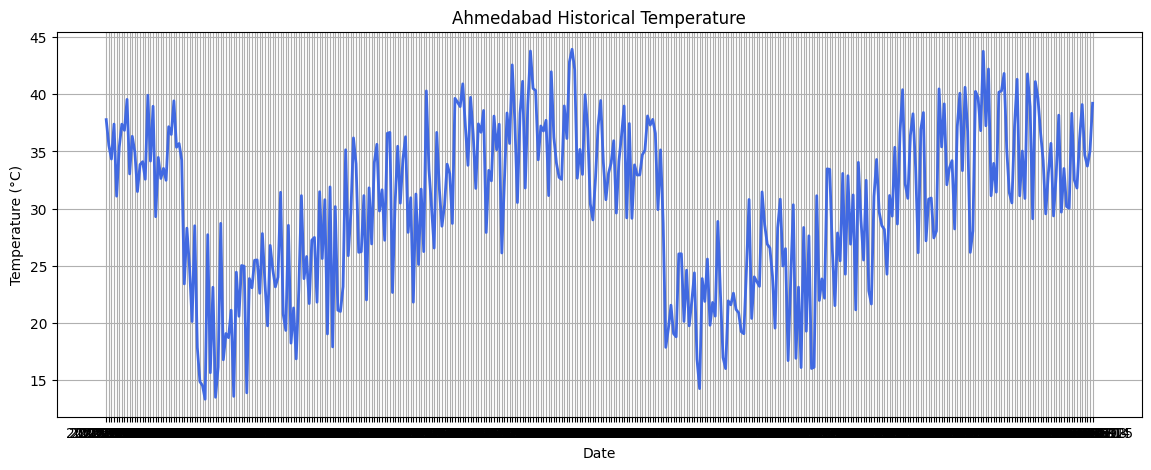

In [195]:
plt.figure(figsize=(14,5))
plt.plot(prophet_df["ds"], prophet_df["y"], color="royalblue", linewidth=2)

plt.title("Ahmedabad Historical Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

### Step 3.5 — Create Prophet Model

In [196]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

### Step 3.6 — Train Model

In [197]:
model.fit(prophet_df)

00:28:53 - cmdstanpy - INFO - Chain [1] start processing
00:28:53 - cmdstanpy - INFO - Chain [1] done processing


### Step 3.7 — Create Future Dates

In [198]:
# Here, "model.make_future_dataframe" is used to create a dataframe that extends into the future for the specified number of periods 
# (60 days in this case) with a daily frequency. This future dataframe will be used to make predictions for the next 60 days based on the 
# historical data that was used to fit the model.
future = model.make_future_dataframe(periods=60, freq="D")
future.tail()

,ds
435,2026-08-10
436,2026-08-11
437,2026-08-12
438,2026-08-13
439,2026-08-14


### Step 3.8 — Forecast

In [199]:
# Here, model.predict is used to generate forecasts for the future dates specified in the "future" dataframe. 
# The resulting "forecast" dataframe will contain the predicted values along with additional information such as confidence intervals and trend components.
forecast = model.predict(future)
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2025-06-01,30.519179,28.663781,39.886805,30.519179,30.519179,3.797506,3.797506,3.797506,-0.057391,-0.057391,-0.057391,3.854896,3.854896,3.854896,0.0,0.0,0.0,34.316684
1,2025-06-02,30.516558,28.869595,40.024606,30.516558,30.516558,4.021579,4.021579,4.021579,0.177484,0.177484,0.177484,3.844094,3.844094,3.844094,0.0,0.0,0.0,34.538137
2,2025-06-03,30.513937,29.782892,40.960616,30.513937,30.513937,4.775328,4.775328,4.775328,0.897147,0.897147,0.897147,3.878181,3.878181,3.878181,0.0,0.0,0.0,35.289265
3,2025-06-04,30.511316,29.209296,39.617934,30.511316,30.511316,3.762915,3.762915,3.762915,-0.192837,-0.192837,-0.192837,3.955752,3.955752,3.955752,0.0,0.0,0.0,34.274231
4,2025-06-05,30.508695,29.312615,40.176577,30.508695,30.508695,4.425734,4.425734,4.425734,0.351773,0.351773,0.351773,4.073961,4.073961,4.073961,0.0,0.0,0.0,34.934430


### Step 3.9 — Display Important Columns

In [200]:
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(10)

,ds,yhat,yhat_lower,yhat_upper
430,2026-08-05,23.898264,18.331088,29.040050
431,2026-08-06,24.435579,19.275627,29.824676
432,2026-08-07,24.003549,18.644802,29.689543
433,2026-08-08,22.773874,17.189209,28.043729
434,2026-08-09,23.734720,18.039958,28.916005
435,2026-08-10,23.809044,18.375002,29.234213
436,2026-08-11,24.351983,18.757760,29.556176
437,2026-08-12,23.079120,17.867932,28.297174
438,2026-08-13,23.444793,18.127079,28.853589
439,2026-08-14,22.904697,17.368150,27.846173


### Step 3.10 — Plot Forecast

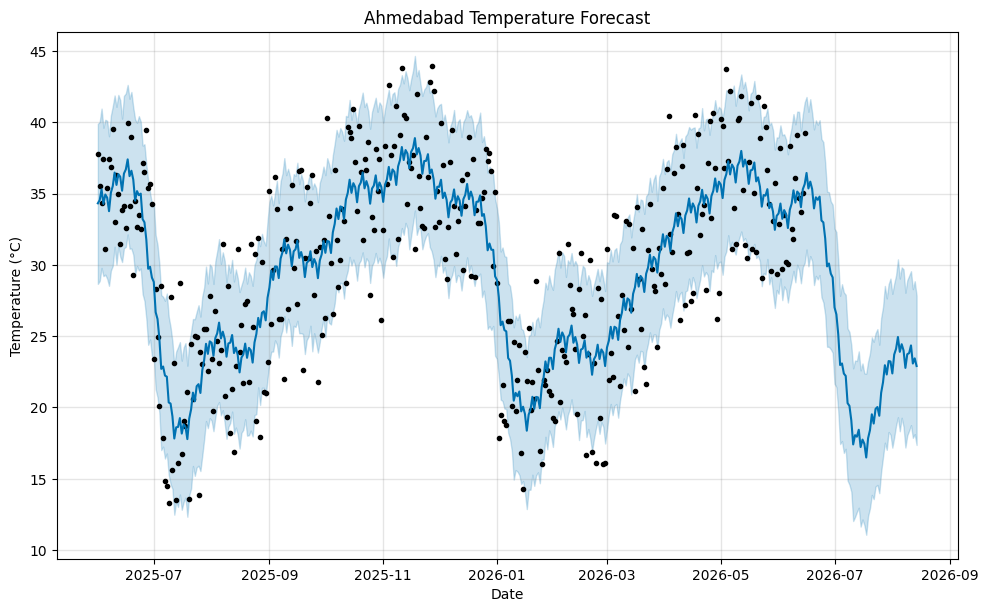

In [201]:
fig = model.plot(forecast)

plt.title("Ahmedabad Temperature Forecast")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

### Step 3.11 — Plot Components

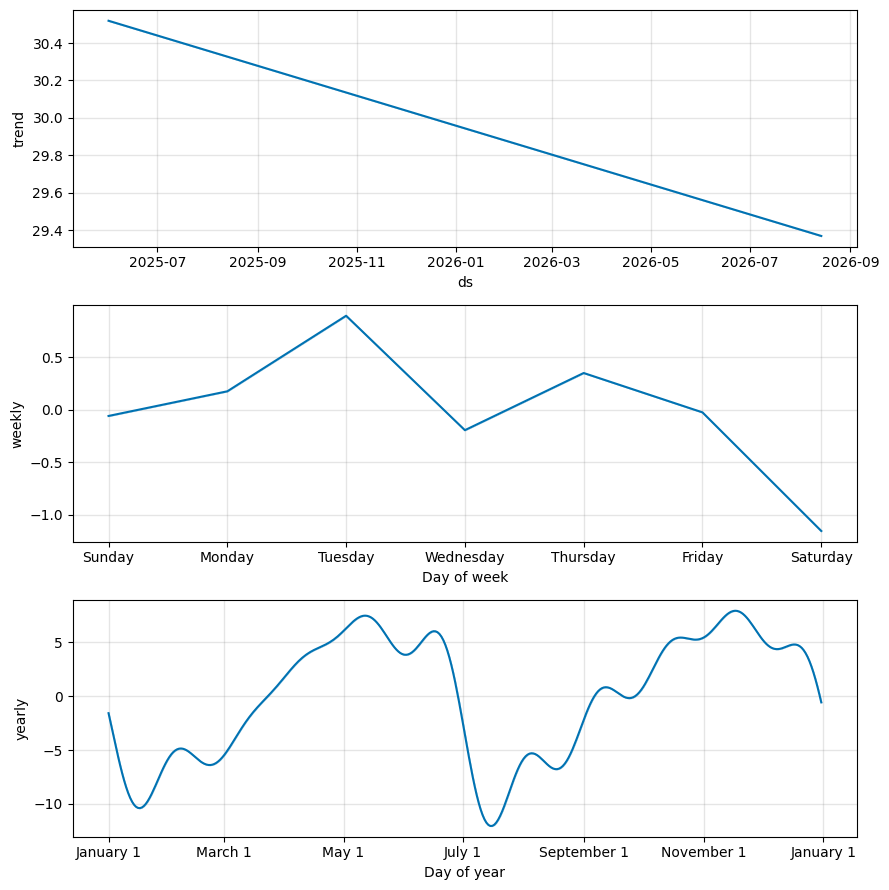

In [202]:
# Here, model.plot_components is used to visualize the individual components of the forecast, such as trend, yearly seasonality, and 
# weekly seasonality.
model.plot_components(forecast)
plt.show()

### Step 3.12 — Predict One Date

In [203]:
target_date = "2026-07-30"

prediction = forecast.loc[
    forecast["ds"] == target_date,
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
]

prediction

,ds,yhat,yhat_lower,yhat_upper
424,2026-07-30,23.253787,18.272939,28.647442


### Step 3.13 — Save Model

In [204]:
os.makedirs("../sample_weather_models", exist_ok=True)
joblib.dump(model, "../sample_weather_models/Ahmedabad_temperature.pkl")

['../sample_weather_models/Ahmedabad_temperature.pkl']

In [205]:
print(os.listdir("../sample_weather_models"))

['Ahmedabad_temperature.pkl']


In [206]:
# Delete the existing model folder sample_weather_models
import shutil

if os.path.exists("../sample_weather_models"):
    shutil.rmtree("../sample_weather_models")
    print("Deleted existing folder: sample_weather_models")

Deleted existing folder: sample_weather_models


## 🌦️ PHASE 4 — Train Temperature Models for All 20 Cities

### Step 4.1 — Create Models Folder

In [207]:
os.makedirs("../temp_weather_models", exist_ok=True)

### Step 4.2 — Get All Cities

In [208]:
cities = sorted(Weather_Forecast["City"].unique())

print(cities)
print(f"Total Cities: {len(cities)}")

['Ahmedabad', 'Bengaluru', 'Bhopal', 'Chennai', 'Delhi', 'Goa', 'Hyderabad', 'Jaipur', 'Kanpur', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai', 'Mysuru', 'Nagpur', 'Patna', 'Pune', 'Surat', 'Varanasi', 'Visakhapatnam']
Total Cities: 20


### Step 4.3 — Train All Temperature Models

In [209]:
from prophet import Prophet
import joblib

for city in cities:
    print(f"Training Model for {city}...")
    city_df = Weather_Forecast[Weather_Forecast["City"] == city].copy()
    prophet_df = city_df[["Date", "Temperature"]].copy()
    prophet_df.columns = ["ds", "y"]

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False
    )

    model.fit(prophet_df)
    model_path = f"../temp_weather_models/{city}_temperature.pkl"
    joblib.dump(model, model_path)
    print(f"Saved -> {model_path}")

print("\n✅ All Temperature Models Trained Successfully!")

Training Model for Ahmedabad...


00:28:54 - cmdstanpy - INFO - Chain [1] start processing
00:28:55 - cmdstanpy - INFO - Chain [1] done processing
00:28:55 - cmdstanpy - INFO - Chain [1] start processing


Saved -> ../temp_weather_models/Ahmedabad_temperature.pkl
Training Model for Bengaluru...


00:28:55 - cmdstanpy - INFO - Chain [1] done processing
00:28:55 - cmdstanpy - INFO - Chain [1] start processing
00:28:55 - cmdstanpy - INFO - Chain [1] done processing


Saved -> ../temp_weather_models/Bengaluru_temperature.pkl
Training Model for Bhopal...
Saved -> ../temp_weather_models/Bhopal_temperature.pkl
Training Model for Chennai...


...

Saved -> ../temp_weather_models/Patna_temperature.pkl
Training Model for Pune...
Saved -> ../temp_weather_models/Pune_temperature.pkl
Training Model for Surat...


00:28:58 - cmdstanpy - INFO - Chain [1] start processing
00:28:58 - cmdstanpy - INFO - Chain [1] done processing
00:28:59 - cmdstanpy - INFO - Chain [1] start processing
00:28:59 - cmdstanpy - INFO - Chain [1] done processing


Saved -> ../temp_weather_models/Surat_temperature.pkl
Training Model for Varanasi...
Saved -> ../temp_weather_models/Varanasi_temperature.pkl
Training Model for Visakhapatnam...


00:28:59 - cmdstanpy - INFO - Chain [1] start processing
00:28:59 - cmdstanpy - INFO - Chain [1] done processing


Saved -> ../temp_weather_models/Visakhapatnam_temperature.pkl

✅ All Temperature Models Trained Successfully!


### Step 4.4 — Verify

In [210]:
models = os.listdir("../weather_models")
print(models)
print(f"\nTotal Models: {len(models)}")

['Ahmedabad_temperature.pkl', 'Bengaluru_temperature.pkl', 'Bhopal_temperature.pkl', 'Chennai_temperature.pkl', 'Delhi_temperature.pkl', 'Goa_temperature.pkl', 'Humidity', 'Hyderabad_temperature.pkl', 'Jaipur_temperature.pkl', 'Kanpur_temperature.pkl', 'Kochi_temperature.pkl', 'Kolkata_temperature.pkl', 'Lucknow_temperature.pkl', 'Mumbai_temperature.pkl', 'Mysuru_temperature.pkl', 'Nagpur_temperature.pkl', 'Patna_temperature.pkl', 'Pressure', 'Pune_temperature.pkl', 'Surat_temperature.pkl', 'Temperature', 'Varanasi_temperature.pkl', 'Visakhapatnam_temperature.pkl', 'WindSpeed']

Total Models: 24


### Step 4.5 — Test One Model

In [211]:
model = joblib.load("../temp_weather_models/Kolkata_temperature.pkl")

future = model.make_future_dataframe(periods=30, freq="D")
forecast = model.predict(future)
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
405,2026-07-11,28.697279,16.885068,25.753317,28.697024,28.697523,-7.330789,-7.330789,-7.330789,-0.387064,-0.387064,-0.387064,-6.943726,-6.943726,-6.943726,0.0,0.0,0.0,21.366490
406,2026-07-12,28.700365,17.915865,26.799273,28.700093,28.700620,-6.599196,-6.599196,-6.599196,0.771759,0.771759,0.771759,-7.370955,-7.370955,-7.370955,0.0,0.0,0.0,22.101169
407,2026-07-13,28.703451,16.938973,25.292944,28.703160,28.703718,-7.384341,-7.384341,-7.384341,0.344771,0.344771,0.344771,-7.729112,-7.729112,-7.729112,0.0,0.0,0.0,21.319110
408,2026-07-14,28.706537,15.853959,24.372966,28.706225,28.706820,-8.635874,-8.635874,-8.635874,-0.621795,-0.621795,-0.621795,-8.014079,-8.014079,-8.014079,0.0,0.0,0.0,20.070663
409,2026-07-15,28.709622,16.659260,25.693305,28.709289,28.709922,-7.576821,-7.576821,-7.576821,0.646440,0.646440,0.646440,-8.223261,-8.223261,-8.223261,0.0,0.0,0.0,21.132801


### Step 4.6 — Predict Any Date & Visualize

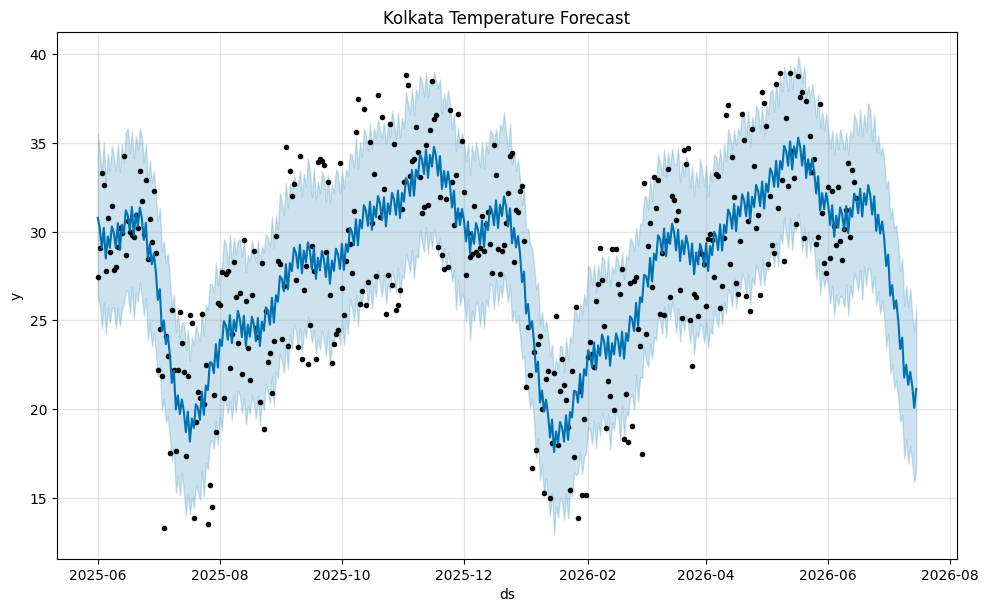

In [212]:
target = "2026-07-25"

forecast.loc[
    forecast["ds"] == target,
    ["ds", "yhat"]
]

fig = model.plot(forecast)
plt.title("Kolkata Temperature Forecast")
plt.show()

In [213]:
# Delete old temperature models
# Delete the existing model folder sample_weather_models
import shutil

if os.path.exists("../temp_weather_models"):
    shutil.rmtree("../temp_weather_models")
    print("Deleted existing folder: temp_weather_models")

print("Old temperature models deleted successfully.")

Deleted existing folder: temp_weather_models
Old temperature models deleted successfully.


## 🌦️ PHASE 5 — Forecast All Weather Parameters

### Step 5.1 — Create Folder Structure

In [224]:
Weather_Forecast

,UpdatedAt,Country,CountryCode,State,StateCode,City,CityID,Latitude,Longitude,WeatherCondition,...,NO,NO2,O3,SO2,PM25,PM10,NH3,CreatedAt,Date,AQI_Category
0,2025-06-01 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Rain,...,4.43,38.19,70.04,10.91,36.54,53.71,3.60,2025-06-01 12:00:00,2025-06-01,Satisfactory
1,2025-06-02 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Rain,...,8.74,20.16,42.95,7.57,48.00,68.64,14.81,2025-06-02 12:00:00,2025-06-02,Satisfactory
2,2025-06-03 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Thunderstorm,...,14.69,20.85,31.69,9.73,37.52,53.28,13.21,2025-06-03 12:00:00,2025-06-03,Satisfactory
3,2025-06-04 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clear,...,16.81,54.36,56.80,4.64,63.84,91.93,14.59,2025-06-04 12:00:00,2025-06-04,Moderate
4,2025-06-05 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clouds,...,15.13,9.56,16.31,20.10,57.96,89.84,10.07,2025-06-05 12:00:00,2025-06-05,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7595,2026-06-11 12:00:00,India,IN,Andhra Pradesh,AP,Visakhapatnam,1252783,17.6868,83.2185,Thunderstorm,...,5.72,50.88,49.81,26.58,44.66,70.56,12.09,2026-06-11 12:00:00,2026-06-11,Satisfactory
7596,2026-06-12 12:00:00,India,IN,Andhra Pradesh,AP,Visakhapatnam,1252783,17.6868,83.2185,Rain,...,10.65,47.86,27.56,29.87,35.99,55.78,3.02,2026-06-12 12:00:00,2026-06-12,Satisfactory
7597,2026-06-13 12:00:00,India,IN,Andhra Pradesh,AP,Visakhapatnam,1252783,17.6868,83.2185,Rain,...,0.81,31.52,76.52,16.95,43.89,53.11,5.38,2026-06-13 12:00:00,2026-06-13,Satisfactory
7598,2026-06-14 12:00:00,India,IN,Andhra Pradesh,AP,Visakhapatnam,1252783,17.6868,83.2185,Thunderstorm,...,1.81,20.91,71.71,14.73,30.78,38.78,10.51,2026-06-14 12:00:00,2026-06-14,Satisfactory


In [214]:
parameters = ["Temperature", "Humidity", "Pressure", "WindSpeed"]

for parameter in parameters:
    os.makedirs(f"../weather_models/{parameter}", exist_ok=True)

print("Folders Created Successfully!")

Folders Created Successfully!


### Step 5.2 — Create a Reusable Function

In [215]:
def train_weather_model(city, parameter):

    city_df = Weather_Forecast[Weather_Forecast["City"] == city].copy()
    prophet_df = city_df[["Date", parameter]].copy()

    prophet_df.columns = ["ds", "y"]

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False
    )

    model.fit(prophet_df)
    path = f"../weather_models/{parameter}/{city}.pkl"
    joblib.dump(model, path)
    return path

### Step 5.3 — Train Every Model

In [216]:
cities = sorted(Weather_Forecast["City"].unique())
parameters = ["Temperature", "Humidity", "Pressure", "WindSpeed"]

for parameter in parameters:
    print(f"\nTraining {parameter} Models...\n")

    for city in cities:
        path = train_weather_model(city, parameter)
        print(f"Saved -> {path}")

print("\nAll Weather Models Created Successfully!")


Training Temperature Models...



00:29:00 - cmdstanpy - INFO - Chain [1] start processing
00:29:00 - cmdstanpy - INFO - Chain [1] done processing
00:29:00 - cmdstanpy - INFO - Chain [1] start processing


Saved -> ../weather_models/Temperature/Ahmedabad.pkl


00:29:00 - cmdstanpy - INFO - Chain [1] done processing
00:29:00 - cmdstanpy - INFO - Chain [1] start processing
00:29:00 - cmdstanpy - INFO - Chain [1] done processing


Saved -> ../weather_models/Temperature/Bengaluru.pkl
Saved -> ../weather_models/Temperature/Bhopal.pkl


...

Saved -> ../weather_models/WindSpeed/Surat.pkl


00:29:15 - cmdstanpy - INFO - Chain [1] done processing
00:29:15 - cmdstanpy - INFO - Chain [1] start processing


Saved -> ../weather_models/WindSpeed/Varanasi.pkl


00:29:16 - cmdstanpy - INFO - Chain [1] done processing


Saved -> ../weather_models/WindSpeed/Visakhapatnam.pkl

All Weather Models Created Successfully!


### Step 5.4 — Verify

In [217]:
for parameter in parameters:
    models = os.listdir(f"../weather_models/{parameter}")
    print(parameter)
    print(len(models))
    print("-"*40)

Temperature
20
----------------------------------------
Humidity
20
----------------------------------------
Pressure
20
----------------------------------------
WindSpeed
20
----------------------------------------


### Step 5.5 — Test One Model

In [218]:
# Temperature
model = joblib.load("../weather_models/Temperature/Kolkata.pkl")
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
405,2026-07-11,28.697279,16.838578,25.406779,28.697068,28.697520,-7.330789,-7.330789,-7.330789,-0.387064,-0.387064,-0.387064,-6.943726,-6.943726,-6.943726,0.0,0.0,0.0,21.366490
406,2026-07-12,28.700365,17.916690,26.841166,28.700138,28.700618,-6.599196,-6.599196,-6.599196,0.771759,0.771759,0.771759,-7.370955,-7.370955,-7.370955,0.0,0.0,0.0,22.101169
407,2026-07-13,28.703451,17.035836,25.810226,28.703210,28.703722,-7.384341,-7.384341,-7.384341,0.344771,0.344771,0.344771,-7.729112,-7.729112,-7.729112,0.0,0.0,0.0,21.319110
408,2026-07-14,28.706537,15.711941,24.633905,28.706274,28.706828,-8.635874,-8.635874,-8.635874,-0.621795,-0.621795,-0.621795,-8.014079,-8.014079,-8.014079,0.0,0.0,0.0,20.070663
409,2026-07-15,28.709622,16.808163,25.393357,28.709344,28.709928,-7.576821,-7.576821,-7.576821,0.646440,0.646440,0.646440,-8.223261,-8.223261,-8.223261,0.0,0.0,0.0,21.132801


In [219]:
# Humidity
model = joblib.load("../weather_models/Humidity/Kolkata.pkl")
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
405,2026-07-11,75.603734,57.148194,75.538693,75.603733,75.603735,-9.528217,-9.528217,-9.528217,-0.215837,-0.215837,-0.215837,-9.312380,-9.312380,-9.312380,0.0,0.0,0.0,66.075517
406,2026-07-12,75.600225,56.545929,75.482146,75.600223,75.600226,-9.680082,-9.680082,-9.680082,0.218029,0.218029,0.218029,-9.898111,-9.898111,-9.898111,0.0,0.0,0.0,65.920142
407,2026-07-13,75.596715,54.720451,74.168430,75.596714,75.596716,-11.032407,-11.032407,-11.032407,-0.659105,-0.659105,-0.659105,-10.373302,-10.373302,-10.373302,0.0,0.0,0.0,64.564308
408,2026-07-14,75.593206,55.840636,73.777059,75.593205,75.593207,-10.714940,-10.714940,-10.714940,0.022317,0.022317,0.022317,-10.737257,-10.737257,-10.737257,0.0,0.0,0.0,64.878266
409,2026-07-15,75.589696,55.663134,74.462100,75.589695,75.589698,-10.639945,-10.639945,-10.639945,0.351482,0.351482,0.351482,-10.991426,-10.991426,-10.991426,0.0,0.0,0.0,64.949752


### Step 5.6 — Create Forecast Function

In [220]:
def forecast_weather(city, parameter, target_date):
    model = joblib.load(f"../weather_models/{parameter}/{city}.pkl")
    future = model.make_future_dataframe(periods=365)
    
    forecast = model.predict(future)
    prediction = forecast[forecast["ds"] == pd.to_datetime(target_date)]

    return prediction["yhat"].iloc[0]

In [221]:
# Temperature
forecast_weather(
    "Delhi",
    "Temperature",
    "2026-08-10"
)

np.float64(13.110656411529778)

In [222]:
# Humidity
forecast_weather(
    "Delhi",
    "Humidity",
    "2026-08-10"
)

np.float64(54.82253461101192)

### Step 5.7 — Forecast All Parameters Together

In [223]:
city = "Delhi"
date = "2026-08-10"
temperature = forecast_weather(city, "Temperature", date)
humidity = forecast_weather(city, "Humidity", date)
pressure = forecast_weather(city, "Pressure", date)
wind = forecast_weather(city, "WindSpeed", date)

print(f"""
Temperature : {temperature:.1f}°C
Humidity : {humidity:.1f}%
Pressure : {pressure:.0f} hPa
Wind Speed : {wind:.1f} km/h""")


Temperature : 13.1°C
Humidity : 54.8%
Pressure : 1009 hPa
Wind Speed : 4.3 km/h
